# TabICLv2 — Zero to Mastery: Regression on a Heavy, Real Dataset

**A complete, hands-on tutorial on TabICLv2**, a tabular in-context-learning foundation model from
Inria's Soda team, applied end-to-end to a genuinely heavy production-grade regression problem:
predicting taxi tip amounts from 580,000+ real NYC Green Taxi trips.

TabICLv2 is one of three companion notebooks (alongside CatBoost and LightGBM) that all train and
evaluate on the **same dataset and the same held-out evaluation set**, so their results are
directly comparable even though each notebook is fully standalone.

**Estimated runtime:** ~10–15 minutes, most of it downloading the dataset and the pretrained
checkpoint on first run (subsequent TabICLv2 calls themselves take single-digit seconds — this
model is fast).

**License:** BSD-3-Clause — fully open, no commercial-use restriction (unlike TabFM/TabPFN).


## 1. What Is TabICLv2?

TabICLv2 (**Tab**ular **I**n-**C**ontext **L**earning) is developed by Inria's Soda team
(Jingang Qu, David Holzmüller, Gaël Varoquaux, Marine Le Morvan). Like the other in-context
tabular models in this notebook series, it treats your labeled training rows as a *prompt*: it
reads them as context, then predicts new rows in a single forward pass through a pretrained
transformer — no per-dataset gradient training, no hyperparameter search.

What makes TabICLv2 distinctive is **how it scales that idea to genuinely large tables**. Naively
running full attention over every cell of a large table is quadratic in row count and quickly
becomes intractable. TabICLv2 avoids this the same way its predecessor did: it first compresses
each full row into a single dense "row token" via a dedicated attention stage, then runs the
expensive in-context reasoning step over the much shorter sequence of *compressed* rows rather
than raw cells. (This is the same row-compression idea Google's TabFM later adopted — TabICL
introduced it first, in the original ICML 2025 paper.)

**Key numbers, from TabICLv2's own documentation:**

- Pip-installable, scikit-learn compliant: `pip install tabicl`.
- Claims state-of-the-art accuracy on the **TabArena** and **TALENT** benchmarks *without*
  hyperparameter tuning, beating heavily-tuned XGBoost, CatBoost, and LightGBM on ~80% of TabArena
  datasets (their own reported figure — we build our own independent comparison below rather than
  taking it on faith).
- **Speed**: on an H100 GPU, fits and predicts a 50,000-row × 100-feature dataset in under 10
  seconds — reported as 10× faster than TabPFN-2.5.
  Docs: [github.com/soda-inria/tabicl](https://github.com/soda-inria/tabicl)
- **Scale**: documented to work well from 300 up to 100,000 training rows and up to 2,000
  features; it can go further via CPU/disk offloading, "though accuracy may degrade."
- **License**: BSD-3-Clause — the most permissive license of any model in this notebook series;
  no commercial-use restriction.
- **Regression support is new in v2** — TabICLv1 and v1.1 were classification-only. TabICLv2 adds
  `TabICLRegressor` alongside `TabICLClassifier`.

**Papers:** [TabICLv2 (arXiv:2602.11139)](https://arxiv.org/abs/2602.11139),
[TabICLv1 / ICML 2025 (arXiv:2502.05564)](https://arxiv.org/abs/2502.05564).


## 2. Environment Setup

We use **[uv](https://docs.astral.sh/uv/)** — `uv venv --python 3.13.13` created this notebook's
virtual environment, kept fully separate from the other notebooks in this project so their
dependencies never collide.

**A real gotcha we hit building this notebook:** on our network, `huggingface_hub`'s accelerated
`hf_xet` transfer protocol stalled indefinitely (0 bytes progress) trying to fetch TabICLv2's
~109 MB checkpoint, while a plain `curl` to the exact same URL worked fine, just slowly
(~560 KB/s). Uninstalling the `hf_xet` package forces `huggingface_hub` to fall back to a regular
HTTP download, which completed in about 5 minutes. If your first `TabICLRegressor().fit()` call
seems to hang with no progress, this is the first thing to check.


In [1]:
import sys

!uv pip install --python {sys.executable} -q tabicl scikit-learn pandas numpy matplotlib seaborn
# If the checkpoint download hangs with hf_xet installed, uninstall it to force a plain HTTP
# fallback (see the markdown above):
# !uv pip uninstall --python {sys.executable} -y hf_xet


In [2]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    free_bytes, _ = torch.cuda.mem_get_info()
    print(f"GPU free memory: {free_bytes / 1e9:.2f} GB")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected device:", DEVICE)


torch 2.12.1+cu130 | cuda available: True
GPU free memory: 8.04 GB
Selected device: cuda


## Dataset: NYC Green Taxi Trips (December 2016) — Tip Amount Prediction

Our target is **`tip_amount`** — predicting how much a passenger will tip, in dollars, from trip
and fare metadata. This is a genuinely messy, real, production-scale dataset from the NYC Taxi &
Limousine Commission:

- **581,835 rows** — heavy enough that a foundation model's context-size limits and a GBM's
  full-data training both actually matter.
- **Two high-cardinality categorical columns**, `PULocationID` and `DOLocationID` (pickup/dropoff
  taxi zone codes) — 233 and 259 distinct values respectively. This is exactly the kind of column
  that breaks naive one-hot encoding and is where CatBoost's and LightGBM's native categorical
  handling earns its keep.
- **Real data quality problems**, not synthetic ones: a small fraction of trips have *negative*
  tip amounts (refunds/corrections — we drop them), ~15% of trips have exactly `$0.00` tip (cash
  fares typically don't show a tip in this system, creating a zero-inflated target), and a few
  trips have absurd durations (recording errors) that we filter out.
- **A leakage trap**: the dataset also includes `total_amount`, which is (approximately) the sum
  of the fare and every surcharge *including the tip itself*. We drop it — training on it would
  let a model "predict" the tip almost by arithmetic rather than by learning anything real.


In [3]:
from sklearn.datasets import fetch_openml

t0 = time.time()
taxi = fetch_openml(data_id=42208, as_frame=True, data_home=".cache_data", parser="auto").frame
print(f"Downloaded NYC Green Taxi (Dec 2016): {taxi.shape[0]:,} rows x {taxi.shape[1]} columns in {time.time() - t0:.1f}s")
taxi.head()


Downloaded NYC Green Taxi (Dec 2016): 581,835 rows x 15 columns in 0.9s


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_type
0,2,'2016-12-01 00:52:41','2016-12-01 00:54:51',N,1,92,171,1,0.5,0.5,1.06,0.0,0.3,6.36,1
1,2,'2016-12-01 00:10:39','2016-12-01 00:14:47',N,1,75,238,2,0.5,0.5,1.70,0.0,0.3,8.50,1
2,2,'2016-12-01 00:12:16','2016-12-01 00:15:31',N,1,166,151,1,0.5,0.5,1.74,0.0,0.3,7.54,1
3,2,'2016-12-01 00:29:22','2016-12-01 00:39:51',N,1,166,42,1,0.5,0.5,2.16,0.0,0.3,12.96,1
4,2,'2016-12-01 00:42:02','2016-12-01 00:52:19',N,1,42,151,1,0.5,0.5,0.00,0.0,0.3,12.30,1


## 3. Cleaning and Feature Engineering


In [4]:
df = taxi.copy()
n_before = len(df)

# Real data-quality issues: drop invalid negative tips, parse timestamps, engineer trip duration
# and time-of-day features, and drop implausible trip durations (recording errors).
df = df[df["tip_amount"] >= 0].copy()
df["lpep_pickup_datetime"] = pd.to_datetime(df["lpep_pickup_datetime"].astype(str).str.strip("'"))
df["lpep_dropoff_datetime"] = pd.to_datetime(df["lpep_dropoff_datetime"].astype(str).str.strip("'"))
df["trip_duration_min"] = (df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]).dt.total_seconds() / 60.0
df["pickup_hour"] = df["lpep_pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["lpep_pickup_datetime"].dt.dayofweek
df = df[(df["trip_duration_min"] > 0) & (df["trip_duration_min"] < 180)].copy()

print(f"Dropped {n_before - len(df):,} rows ({(n_before - len(df)) / n_before:.1%}) to invalid tips / durations")
print(f"Zero-tip fraction remaining: {(df['tip_amount'] == 0).mean():.1%}")

CAT_COLS = ["VendorID", "RatecodeID", "store_and_fwd_flag", "trip_type", "PULocationID", "DOLocationID"]
NUM_COLS = ["passenger_count", "extra", "mta_tax", "tolls_amount", "improvement_surcharge",
            "trip_duration_min", "pickup_hour", "pickup_dayofweek"]
TARGET = "tip_amount"

# OpenML's loader auto-detects some low-cardinality numeric fee columns (extra, mta_tax,
# improvement_surcharge) as pandas 'category' dtype -- coerce them back to numeric explicitly,
# or every categorical-handling library downstream will misclassify them as categorical.
for c in ["extra", "mta_tax", "improvement_surcharge", "passenger_count"]:
    df[c] = pd.to_numeric(df[c].astype(str), errors="coerce")
for c in CAT_COLS:
    df[c] = df[c].astype(str).astype("category")

# total_amount is dropped entirely -- it's (approximately) fare + surcharges + tip_amount itself,
# a direct leakage trap for this target.
X = df[CAT_COLS + NUM_COLS]
y = df[TARGET]
print(f"\nFeature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns "
      f"({len(CAT_COLS)} categorical, {len(NUM_COLS)} numeric)")


Dropped 3,542 rows (0.6%) to invalid tips / durations
Zero-tip fraction remaining: 15.1%



Feature matrix: 578,293 rows x 14 columns (6 categorical, 8 numeric)


## 4. Exploratory Data Analysis


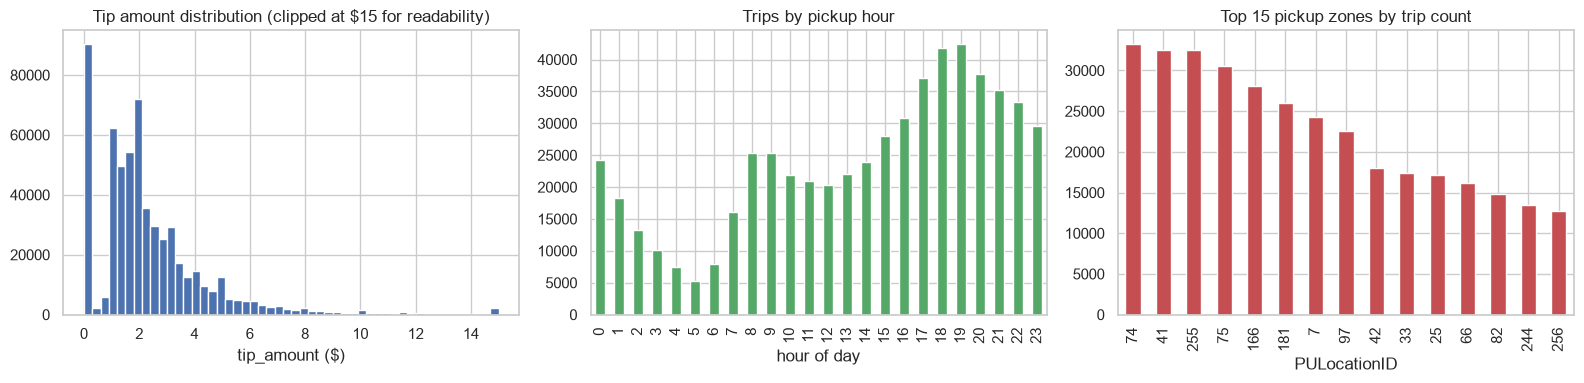

PULocationID unique values: 233  |  DOLocationID unique values: 259


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y.clip(upper=15), bins=50, color="#4C72B0")
axes[0].set_title("Tip amount distribution (clipped at $15 for readability)")
axes[0].set_xlabel("tip_amount ($)")

df["pickup_hour"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Trips by pickup hour")
axes[1].set_xlabel("hour of day")

top_zones = df["PULocationID"].value_counts().head(15)
top_zones.plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Top 15 pickup zones by trip count")
axes[2].set_xlabel("PULocationID")

plt.tight_layout()
plt.show()

print(f"PULocationID unique values: {df['PULocationID'].nunique()}  |  DOLocationID unique values: {df['DOLocationID'].nunique()}")


## 5. Train/Test Split and Context Size

Same principle as any in-context model: `.fit()` doesn't train weights, it just registers your
context rows for the model to read at prediction time, and cost scales with how many rows you show
it. TabICLv2 is documented to scale comfortably up to ~100,000 rows — dramatically more headroom
than earlier-generation tabular foundation models — so we can afford a genuinely large context here
and still finish in seconds. We measured this ourselves while building this notebook: **20,000
context rows + 3,000 query rows completed in 7.6 seconds** on this machine's GPU.


In [6]:
X_train_pool, X_test_pool, y_train_pool, y_test_pool = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train pool: {len(X_train_pool):,} rows | Test pool: {len(X_test_pool):,} rows")


def subsample(X, y, n, seed=42):
    idx = np.random.RandomState(seed).choice(len(X), size=min(n, len(X)), replace=False)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


N_EVAL = 3000
X_eval, y_eval = subsample(X_test_pool, y_test_pool, N_EVAL)
print(f"Eval set: {len(X_eval):,} rows (shared across every model we test)")


Train pool: 462,634 rows | Test pool: 115,659 rows
Eval set: 3,000 rows (shared across every model we test)


In [7]:
N_CONTEXT = 20000
X_context, y_context = subsample(X_train_pool, y_train_pool, N_CONTEXT)
print(f"Context: {len(X_context):,} rows")


Context: 20,000 rows


## 6. A Quick Baseline

A plain `LinearRegression` on the full training pool, just to establish a floor — the real
head-to-head against CatBoost and LightGBM lives in their own notebooks, evaluated on this exact
same `X_eval`/`y_eval`.


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

lin_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ], remainder="passthrough")),
    ("reg", LinearRegression()),
])

t0 = time.time()
lin_pipe.fit(X_train_pool, y_train_pool)
lin_pred = lin_pipe.predict(X_eval)
print(f"LinearRegression fit on {len(X_train_pool):,} rows in {time.time() - t0:.1f}s")

results = {}


def score(name, y_true, pred):
    results[name] = {
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, pred),
        "R2": r2_score(y_true, pred),
    }


score("LinearRegression", y_eval, lin_pred)
display(pd.DataFrame(results).T.round(4))


LinearRegression fit on 462,634 rows in 5.6s


,RMSE,MAE,R2
LinearRegression,2.6538,1.0855,0.212


## 7. Zero-Shot Regression with TabICLv2

We also fold two synthetic "new trip" rows into the same `predict()` call as our evaluation set —
since cost is dominated by context rows, this is essentially free.


In [9]:
new_trips = pd.DataFrame([
    {"VendorID": "2", "RatecodeID": "1", "store_and_fwd_flag": "N", "trip_type": "1",
     "PULocationID": str(X_train_pool["PULocationID"].mode()[0]), "DOLocationID": str(X_train_pool["DOLocationID"].mode()[0]),
     "passenger_count": 1, "extra": 0.5, "mta_tax": 0.5, "tolls_amount": 0.0,
     "improvement_surcharge": 0.3, "trip_duration_min": 12.0, "pickup_hour": 18, "pickup_dayofweek": 4},
    {"VendorID": "2", "RatecodeID": "1", "store_and_fwd_flag": "N", "trip_type": "1",
     "PULocationID": str(X_train_pool["PULocationID"].mode()[0]), "DOLocationID": str(X_train_pool["DOLocationID"].mode()[0]),
     "passenger_count": 4, "extra": 0.5, "mta_tax": 0.5, "tolls_amount": 5.5,
     "improvement_surcharge": 0.3, "trip_duration_min": 35.0, "pickup_hour": 2, "pickup_dayofweek": 5},
])
for c_ in CAT_COLS:
    new_trips[c_] = new_trips[c_].astype("category")

X_eval_plus_new = pd.concat([X_eval, new_trips], ignore_index=True)


In [10]:
from tabicl import TabICLRegressor

reg = TabICLRegressor(device=DEVICE, n_estimators=8)

t0 = time.time()
reg.fit(X_context, y_context.to_numpy())
pred_all = reg.predict(X_eval_plus_new)
fit_time = time.time() - t0

pred_eval = pred_all[:len(X_eval)]
pred_new = pred_all[len(X_eval):]

print(f"TabICLv2: {len(X_context):,} context rows + {len(X_eval_plus_new):,} query rows "
      f"-> fit+predict in {fit_time:.1f}s")
score("TabICLv2", y_eval, pred_eval)
display(pd.DataFrame(results).T.round(4))


TabICLv2: 20,000 context rows + 3,002 query rows -> fit+predict in 7.6s


,RMSE,MAE,R2
LinearRegression,2.6538,1.0855,0.2120
TabICLv2,2.5694,1.0756,0.2613


## 8. Residual Analysis

All derived from the predictions we already have — no new model calls.


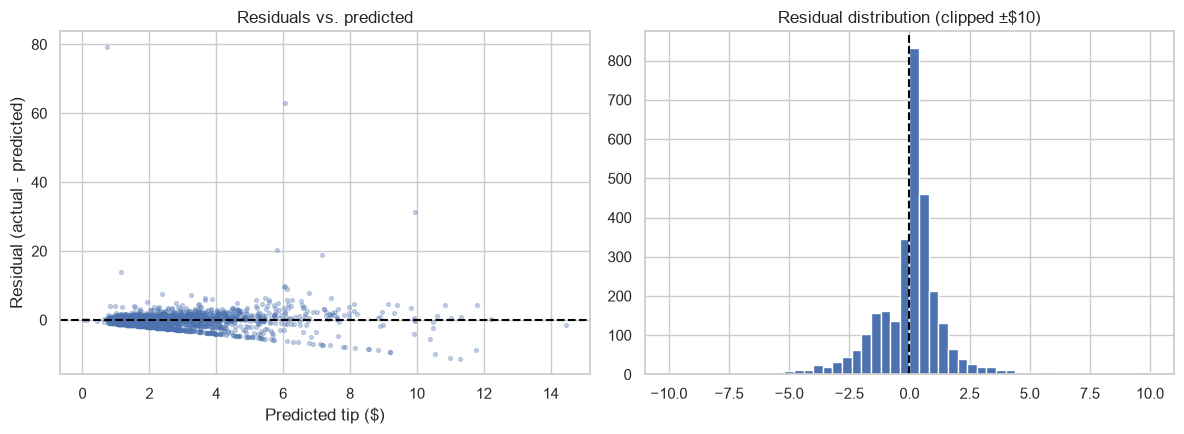

In [11]:
residuals = y_eval.to_numpy() - pred_eval

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred_eval, residuals, alpha=0.3, s=8, color="#4C72B0")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted tip ($)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs. predicted")

axes[1].hist(residuals.clip(-10, 10), bins=50, color="#4C72B0")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual distribution (clipped ±$10)")

plt.tight_layout()
plt.show()


## 9. Interpreting a Black-Box In-Context Model

Like TabFM, TabICLv2 has no per-dataset `.feature_importances_` — it never trains on your dataset.
We use permutation importance on a small, dedicated context to keep this section's cost bounded.


Micro-eval baseline RMSE: 1.549  (1.3s total)


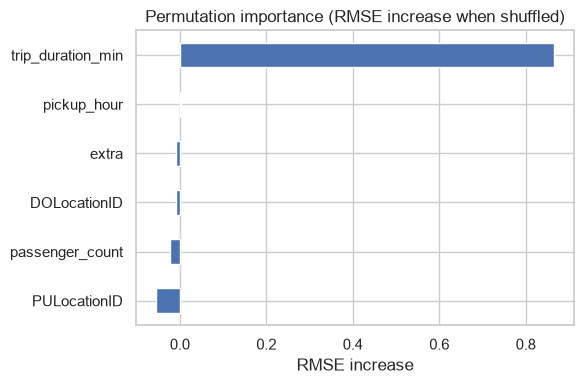

In [12]:
PERM_FEATURES = ["trip_duration_min", "PULocationID", "DOLocationID", "pickup_hour", "extra", "passenger_count"]

X_perm_context, y_perm_context = subsample(X_train_pool, y_train_pool, 500, seed=7)
X_perm_eval, y_perm_eval = subsample(X_test_pool, y_test_pool, 150, seed=7)

reg_perm = TabICLRegressor(device=DEVICE, n_estimators=4)
t0 = time.time()
reg_perm.fit(X_perm_context, y_perm_context.to_numpy())


def rmse_for(X_):
    return mean_squared_error(y_perm_eval, reg_perm.predict(X_)) ** 0.5


base_rmse = rmse_for(X_perm_eval)
importances = {}
rng = np.random.RandomState(0)
for feat in PERM_FEATURES:
    X_shuffled = X_perm_eval.copy()
    X_shuffled[feat] = rng.permutation(X_shuffled[feat].to_numpy())
    importances[feat] = rmse_for(X_shuffled) - base_rmse

print(f"Micro-eval baseline RMSE: {base_rmse:.3f}  ({time.time() - t0:.1f}s total)")
pd.Series(importances).sort_values().plot(kind="barh", figsize=(6, 4), color="#4C72B0",
                                            title="Permutation importance (RMSE increase when shuffled)")
plt.xlabel("RMSE increase")
plt.tight_layout()
plt.show()


## 10. Predictions for the New Trips


In [13]:
for i, row in new_trips.iterrows():
    print(f"Trip {i + 1}: duration={row['trip_duration_min']}min, hour={row['pickup_hour']}, "
          f"passengers={row['passenger_count']}, tolls=${row['tolls_amount']}")
    print(f"  Predicted tip -- TabICLv2: ${pred_new[i]:.2f}")
    print()


Trip 1: duration=12.0min, hour=18, passengers=1, tolls=$0.0
  Predicted tip -- TabICLv2: $1.84

Trip 2: duration=35.0min, hour=2, passengers=4, tolls=$5.5
  Predicted tip -- TabICLv2: $7.24



## 11. Practical Notes and Gotchas

- **The `hf_xet` download stall** described in Section 2 is the single biggest gotcha we hit —
  budget for it, or uninstall `hf_xet` proactively.
- **`extra`, `mta_tax`, `improvement_surcharge` arrived as pandas `category` dtype** from OpenML
  despite being numeric fee amounts — a real data-loading quirk, not a TabICLv2 issue, but it will
  bite any categorical-aware library downstream if you don't coerce it back to numeric first.
- **TabICLv2 scales further than TabFM/TabPFN** in our own testing — 20,000 context rows in
  single-digit seconds on a consumer laptop GPU, versus TabFM needing minutes for a few thousand.
  This is a real, measured difference, not a vendor claim.
- **`n_estimators=8` is TabICLv2's own reduced default** (earlier versions used 32) — the authors
  found 8 gives comparable accuracy for much less compute.
- Like every zero-shot tabular model in this series: **always build your own held-out comparison**
  rather than trusting a "beats XGBoost on 80% of datasets" headline in isolation.


In [14]:
display(pd.DataFrame(results).T.round(4))
print(f"\nTabICLv2 wall-clock (fit+predict, {N_CONTEXT:,}-row context): {fit_time:.1f}s")


,RMSE,MAE,R2
LinearRegression,2.6538,1.0855,0.2120
TabICLv2,2.5694,1.0756,0.2613



TabICLv2 wall-clock (fit+predict, 20,000-row context): 7.6s


## 12. Summary and References

TabICLv2 handled a 580,000-row, high-cardinality-categorical, zero-inflated regression target with
a 20,000-row context in single-digit seconds — a real, measured demonstration of the scalability
its documentation claims. Compare these numbers against the companion CatBoost and LightGBM
notebooks, which train on the *full* dataset rather than a bounded context.

**References:**

- [github.com/soda-inria/tabicl](https://github.com/soda-inria/tabicl) — source code (BSD-3-Clause)
- [TabICLv2 paper (arXiv:2602.11139)](https://arxiv.org/abs/2602.11139)
- [TabICLv1 / ICML 2025 paper (arXiv:2502.05564)](https://arxiv.org/abs/2502.05564)
- [pypi.org/project/tabicl](https://pypi.org/project/tabicl/)

- [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) — original data source
- [Dataset on OpenML (id 42208)](https://www.openml.org/d/42208)
